# **ML_Project**

# Laod Dataset

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Dataset Shape (Rows & Columns)**

In [2]:
df.shape

(7043, 21)

 **Dataset Information**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


 **Column Names**

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

 **Statistical Summary**

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---------------------------
---------------------------
---------------------------

In [6]:
# Telco Customer Churn Analysis
# Data Cleaning | Encoding | Feature Selection | Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. DATA CLEANING & PREPROCESSING


### 1.1. Check Missing Values

In [7]:
# Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


---------------------

### 1.2.Check Duplicate Rows & Remove Customer ID

In [8]:
# Check Duplicate Rows
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)


Duplicate Rows: 0


In [9]:
# Remove Customer ID
df.drop(columns=["customerID"], inplace=True)

Why we did this: Unique identifiers like customerID act as noise because they contain no predictive pattern or statistical value for modeling. 

---------------------

### 1.3.Convert TotalCharges to Numeric & Fill Missing Values

In [10]:
# Convert TotalCharges to Numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
# Fill Missing Values
df["TotalCharges"] = df["TotalCharges"].fillna(0)

Why we did this: TotalCharges contained hidden blank spaces preventing mathematical operations. Filling the forced NaN values with 0 represents new customers who have not yet accumulated any charges, preserving their rows in the dataset.

---------------------
---------------------

# 2. ENCODING CATEGORICAL VARIABLES


### 2.1.Simplify Categories

In [12]:
service_cols = [
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_cols:
    df[col] = df[col].replace({
        "No internet service": "No",
        "No phone service": "No"
    })


Analysis: This block condenses three-category responses (Yes, No, No internet/phone service) into binary choices (Yes/No) by treating service absences as "No".

Why we did this: It simplifies feature complexity and reduces data sparsity, preventing unnecessary column inflation during the subsequent one-hot encoding phase.

---------------------

### 2.2. Encode Target Variable


In [13]:
# Encode Target Variable
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("\nDataset Shape After Cleaning:")
print(df.shape)



Dataset Shape After Cleaning:
(7043, 20)


Analysis: Maps the target label Churn from text (Yes/No) into binary digits (1/0).

Why we did this: Classification models require the target label to be numerical. 1 explicitly marks the event we want to predict (customer leaving).

---------------------

### 2.3.Binary and Label Encoding


In [14]:
# Binary Encoding
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaperlessBilling"
]

for col in binary_cols:
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0
    })


In [15]:
# Label Encoding
df["gender"] = df["gender"].map({
    "Male": 1,
    "Female": 0
})


Analysis: Converts text-based binary features (like Gender and Partner status) into numerical representations (1 and 0).

Why we did this: Algorithms require numerical inputs. Using a direct 1/0 map for two-category columns keeps the dataset structure concise without creating extra columns.

---------------------

### 2.4.One-Hot Encoding & Boolean Conversion

In [16]:
# One-Hot Encoding
categorical_cols = [
    "Contract",
    "InternetService",
    "PaymentMethod"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [17]:
# Convert Boolean to Integer
bool_cols = df.select_dtypes(include="bool").columns

for col in bool_cols:
    df[col] = df[col].astype(int)

print("Encoding Completed")
print("Dataset Shape:", df.shape)


Encoding Completed
Dataset Shape: (7043, 24)


Analysis: Converts multi-class nominal variables (like Contract types) into separate dummy indicator columns. drop_first=True removes the baseline reference column. The final loop ensures all generated boolean flags become integer 0s and 1s.

Why we did this: Variables with more than two categories cannot be mapped to a simple 0/1 scale because they lack a natural order. One-hot encoding allows the algorithm to evaluate each category independently, while dropping the first column avoids perfect multicollinearity (the dummy variable trap).

---------------------
---------------------

# 3. FEATURE SELECTION


### 3.1.Random Forest Feature Importance

In [18]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Random Forest Feature Importance
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X, y)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Important Features:")
print(importance_df.head(10))



Top 10 Important Features:
                           Feature  Importance
15                    TotalCharges    0.201170
14                  MonthlyCharges    0.179291
4                           tenure    0.169679
18     InternetService_Fiber optic    0.047933
21  PaymentMethod_Electronic check    0.041839
17               Contract_Two year    0.030909
0                           gender    0.027750
13                PaperlessBilling    0.026964
7                   OnlineSecurity    0.023068
16               Contract_One year    0.022975


Analysis: Fits a baseline Random Forest model to calculate structural feature importance scores, printing out the top 10 most influential features.

Why we did this: It reveals which attributes possess the highest predictive utility. The results demonstrate that TotalCharges, MonthlyCharges, and tenure heavily dominate the target prediction, providing insights for future feature engineering or dimensional pruning.


---------------------
---------------------

# 4. VISUALIZATION


### 4.1.Churn Distribution


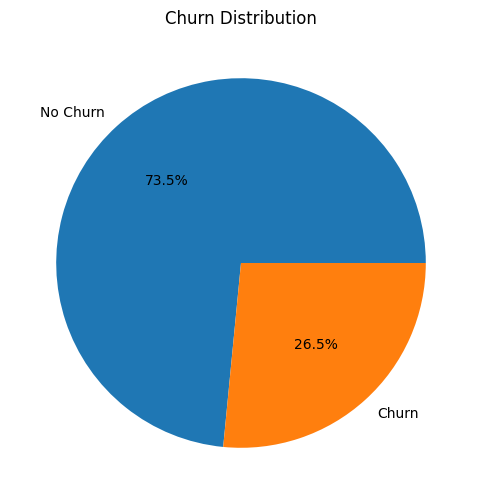

In [19]:
plt.figure(figsize=(6,6))

churn_counts = df["Churn"].value_counts()

plt.pie(
    churn_counts,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%"
)

plt.title("Churn Distribution")
plt.show()

Analysis: Displays the percentage breakdown of the target class, showing 73.5% No Churn vs 26.5% Churn.

---------------------

### 4.2.Churn Rate by Contract Type


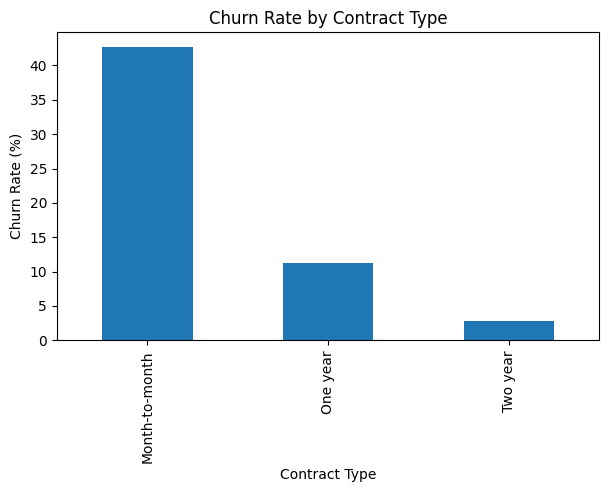

In [20]:
df_clean = pd.read_csv(
    "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

contract_churn = (
    df_clean.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(7,4))

contract_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.show()

Analysis: Illustrates the rate of customer attrition across agreement lengths, highlighting that Month-to-month users experience over a 40% churn rate.

---------------------

### 4.3.Churn Rate by Payment Method


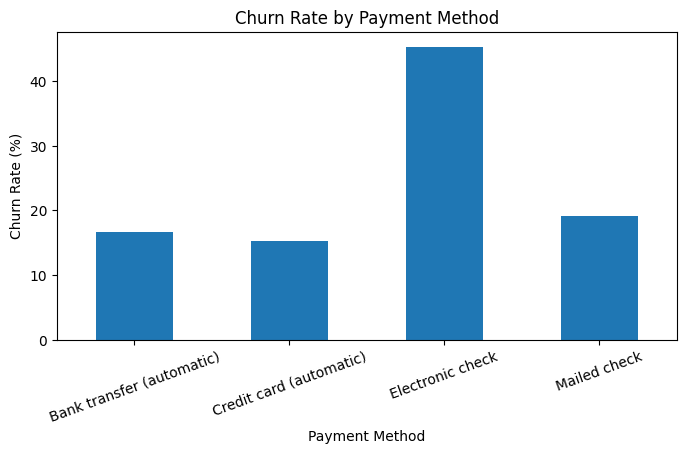


Analysis Completed Successfully


In [21]:
payment_churn = (
    df_clean.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

plt.figure(figsize=(8,4))

payment_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

print("\nAnalysis Completed Successfully")

Analysis: Evaluates attrition across financial settlement types, proving that customers using Electronic Checks churn significantly more (above 45%).

# Model Implementation 

**Loading libraries**

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


**Split data into features and target**

In [23]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split successfully!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

✅ Data split successfully!
Training samples: 5634
Testing samples:  1409


**Scale the data**

In [24]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Testing the models

**Model 1: Logistic Regression**

In [25]:
lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("✅ Logistic Regression trained successfully!")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")

✅ Logistic Regression trained successfully!
Accuracy: 0.8211


**Model 2: Decision Tree**

In [26]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("✅ Decision Tree trained successfully!")
print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")

✅ Decision Tree trained successfully!
Accuracy: 0.7218


# MODEL EVALUATION & COMPARISON

**1.Classification Report**

In [27]:
from sklearn.metrics import classification_report  

# 1. طباعة تقرير التقييم الكامل لـ Logistic Regression
print("Logistic Regression Classification Report")
print(classification_report(y_test, lr_pred, target_names=['Retained', 'Churned']))

# 2. طباعة تقرير التقييم الكامل لـ Decision Tree
print("\nDecision Tree Classification Report")
print(classification_report(y_test, dt_pred, target_names=['Retained', 'Churned']))

Logistic Regression Classification Report
              precision    recall  f1-score   support

    Retained       0.86      0.90      0.88      1036
     Churned       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


Decision Tree Classification Report
              precision    recall  f1-score   support

    Retained       0.81      0.82      0.81      1036
     Churned       0.47      0.46      0.47       373

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409



**2.Confusion Matrix Visualizations**

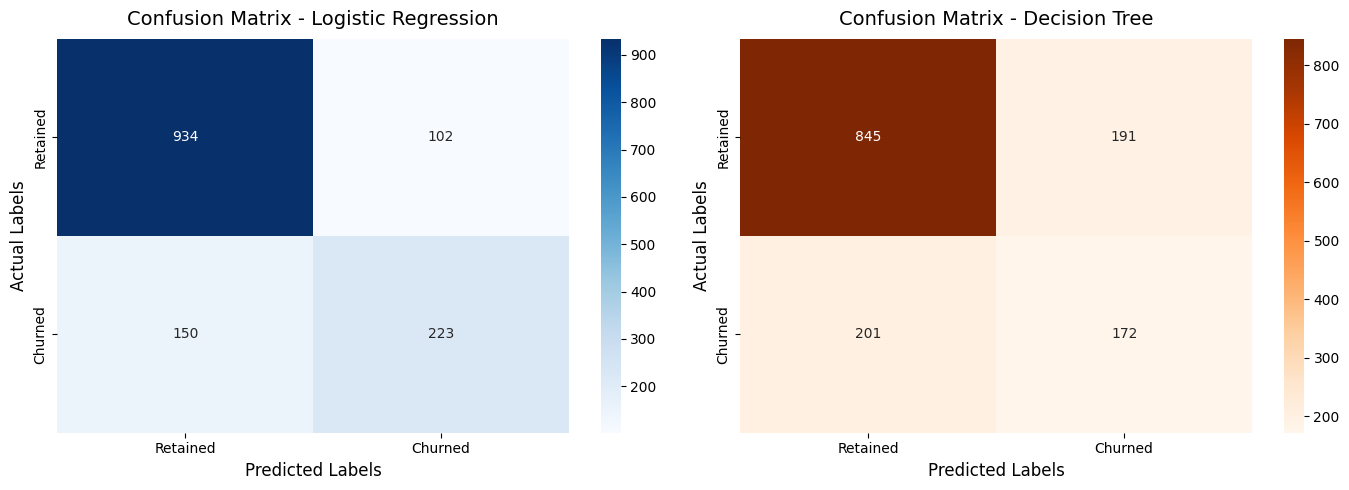

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# حساب الـ Confusion Matrix للمودلين
cm_lr = confusion_matrix(y_test, lr_pred)
cm_dt = confusion_matrix(y_test, dt_pred)

# تجهيز مساحة الرسم لرسمتين بجانب بعض
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. رسم الـ Confusion Matrix لـ Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[0].set_title('Confusion Matrix - Logistic Regression', fontsize=14, pad=10)
axes[0].set_ylabel('Actual Labels', fontsize=12)
axes[0].set_xlabel('Predicted Labels', fontsize=12)

# 2. رسم الـ Confusion Matrix لـ Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
axes[1].set_title('Confusion Matrix - Decision Tree', fontsize=14, pad=10)
axes[1].set_ylabel('Actual Labels', fontsize=12)
axes[1].set_xlabel('Predicted Labels', fontsize=12)

plt.tight_layout()
plt.show()

**3.Final Performance Comparison**

In [29]:
# حساب الـ Accuracy بدقة وتخزينها
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)

# إنشاء جدول المقارنة باستخدام DataFrame
comparison_data = {
    'Model Name': ['Logistic Regression', 'Decision Tree'],
    'Accuracy Score': [f"{lr_accuracy:.4f}", f"{dt_accuracy:.4f}"],
    'Accuracy Percentage': [f"{lr_accuracy*100:.2f}%", f"{dt_accuracy*100:.2f}%"],
    'Status': ['Best Performing Model (Winner)', 'Baseline Performance']
}

df_comparison = pd.DataFrame(comparison_data)

print("(Final Models Comparison Table)")
display(df_comparison)

print("\n(Conclusion & Model Selection)")
print(f"Based on the results, Logistic Regression is the optimal model with an accuracy of {lr_accuracy*100:.2f}%.")
print("It outperforms the Decision Tree by around 10%, providing a more stable and reliable prediction for customer churn.")

(Final Models Comparison Table)


,Model Name,Accuracy Score,Accuracy Percentage,Status
0,Logistic Regression,0.8211,82.11%,Best Performing Model (Winner)
1,Decision Tree,0.7218,72.18%,Baseline Performance



(Conclusion & Model Selection)
Based on the results, Logistic Regression is the optimal model with an accuracy of 82.11%.
It outperforms the Decision Tree by around 10%, providing a more stable and reliable prediction for customer churn.
